In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "books.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8"
)

In [4]:
# authors who have written more books receive more reader engagement
# Calculate books and reviews per author
author_stats = df.groupby("authors").agg({
    "title": "count",
    "text_reviews_count": "sum"
}).reset_index()

author_stats.columns = ["authors", "book_count", "total_reviews"]

author_stats.head()

,authors,book_count,total_reviews
0,A.B. Yehoshua/Hillel Halkin,2,176
1,A.D.P. Briggs/Leo Tolstoy/Fyodor Dostoyevsky,1,1
2,A.E. Cunningham/Harlan Ellison/Charles F. Mill...,1,2
3,A.J. Jacobs,1,2326
4,A.M. Homes,1,518


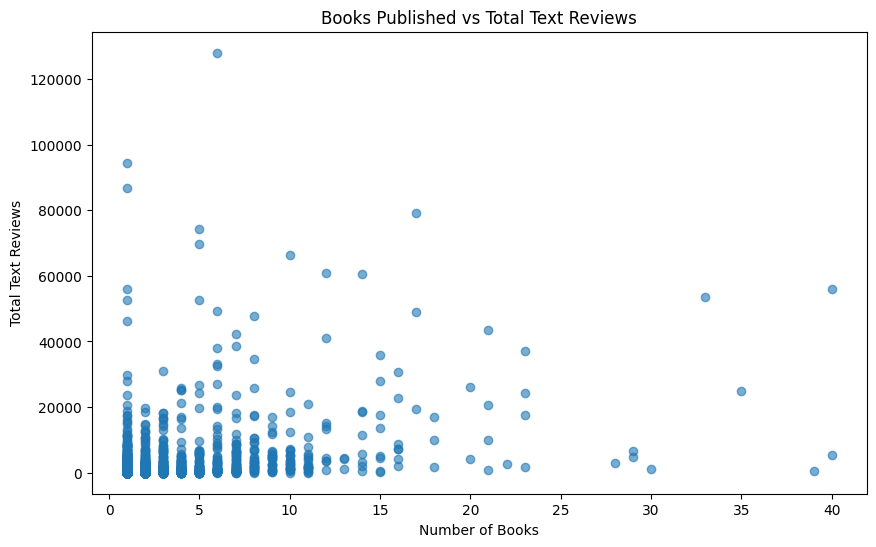

In [5]:
plt.figure(figsize=(10,6))

plt.scatter(
    author_stats["book_count"],
    author_stats["total_reviews"],
    alpha=0.6
)

plt.title("Books Published vs Total Text Reviews")
plt.xlabel("Number of Books")
plt.ylabel("Total Text Reviews")

plt.show()

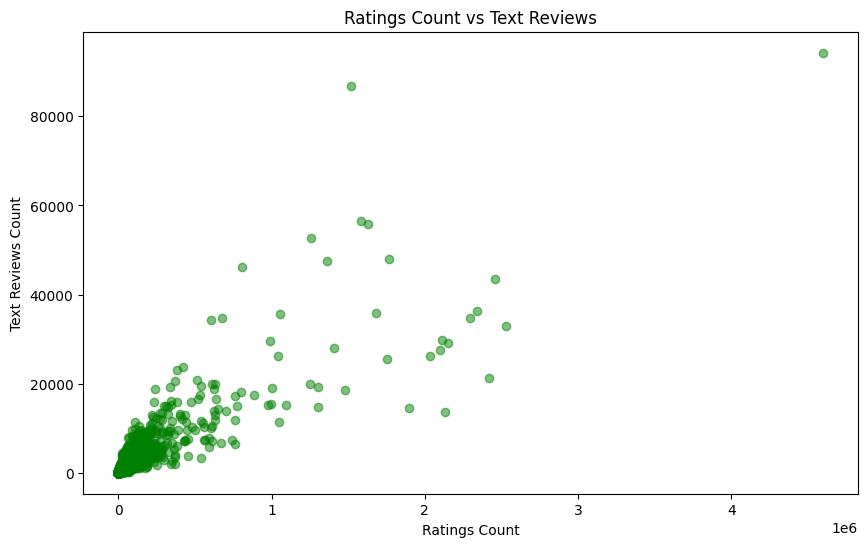

In [6]:
# books with more rating also have more text reviews?
plt.figure(figsize=(10,6))

plt.scatter(
    df["ratings_count"],
    df["text_reviews_count"],
    alpha=0.5,
    color="green"
)

plt.title("Ratings Count vs Text Reviews")
plt.xlabel("Ratings Count")
plt.ylabel("Text Reviews Count")

plt.show()

In [7]:
# publishers consistently publishing highly rated books
publisher_rating = df.groupby("publisher").agg(
    avg_rating=("average_rating","mean"),
    books=("title","count")
)

publisher_rating = publisher_rating[publisher_rating["books"]>=20]

publisher_rating = publisher_rating.sort_values(
    by="avg_rating",
    ascending=False
).head(10)

publisher_rating

,avg_rating,books
publisher,,
Library of America,4.263462,52
Tyndale House Publishers,4.260000,22
VIZ Media LLC,4.242614,88
Viz Media,4.177000,20
Vertigo,4.160714,42
Everyman's Library,4.147436,39
Brilliance Audio,4.110000,21
Harvard University Press,4.107568,37
Houghton Mifflin Harcourt,4.078205,39


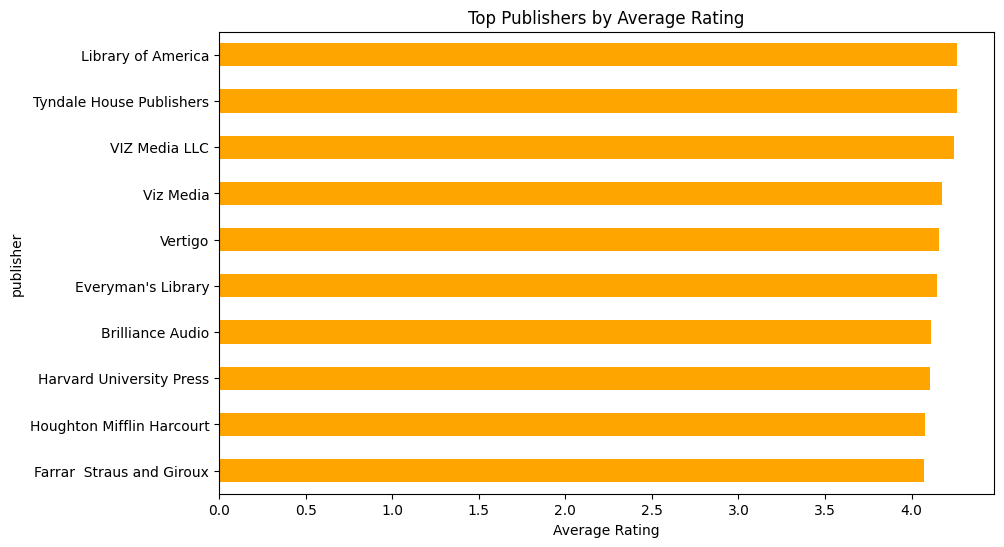

In [8]:
plt.figure(figsize=(10,6))

publisher_rating["avg_rating"].sort_values().plot(
    kind="barh",
    color="orange"
)

plt.title("Top Publishers by Average Rating")
plt.xlabel("Average Rating")

plt.show()

In [11]:
# language having highest average rating
language_rating = df.groupby("language_code").agg(
    avg_rating=("average_rating","mean"),
    books=("title","count")
)

language_rating = language_rating[
    language_rating["books"]>=20
]

language_rating = language_rating.sort_values(
    by="avg_rating",
    ascending=False
)

language_rating.head(10)

,avg_rating,books
language_code,,
jpn,4.268696,46
fre,3.971528,144
ger,3.950101,99
eng,3.934078,8906
spa,3.929312,218
en-GB,3.923411,214
en-US,3.915000,1406


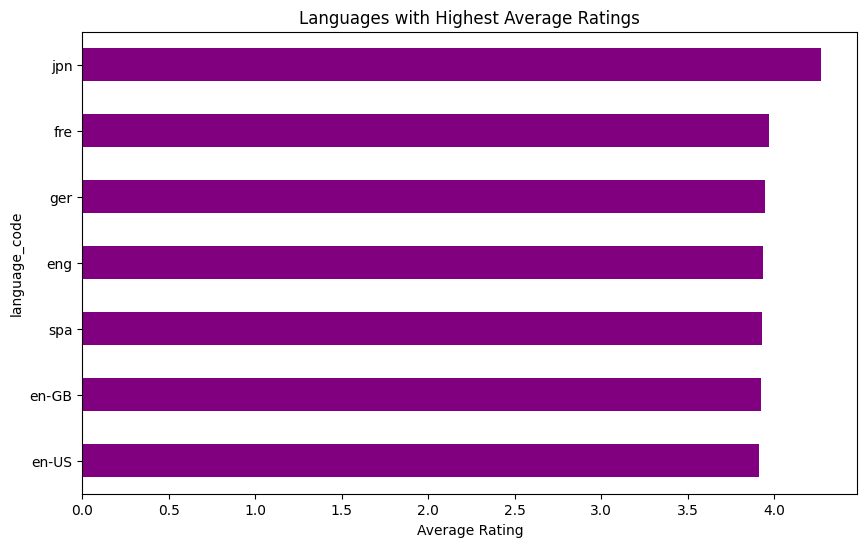

In [12]:
plt.figure(figsize=(10,6))

language_rating.head(10)["avg_rating"].sort_values().plot(
    kind="barh",
    color="purple"
)

plt.title("Languages with Highest Average Ratings")
plt.xlabel("Average Rating")

plt.show()

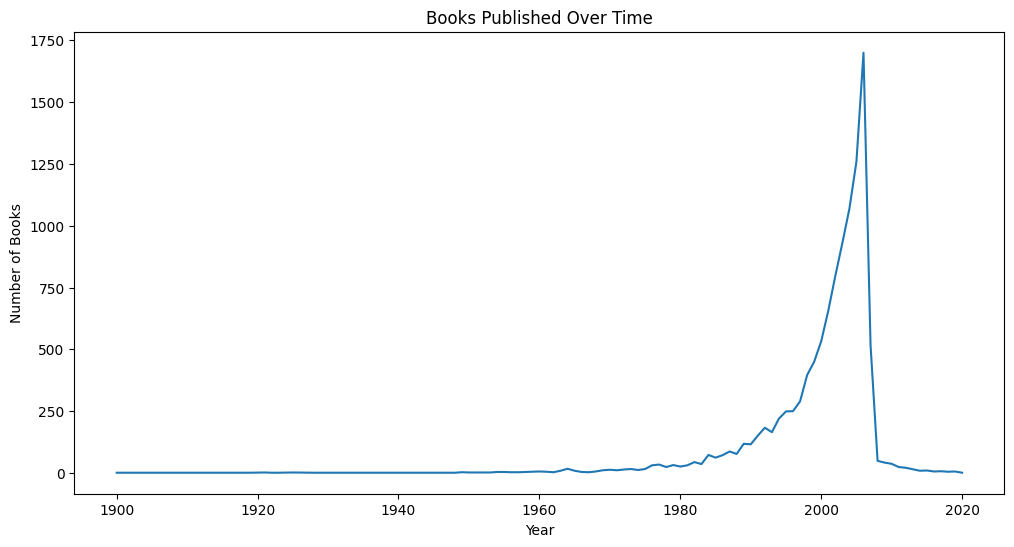

In [13]:
# book publishing changed over time
df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df["year"] = df["publication_date"].dt.year

books_year = df["year"].value_counts().sort_index()

plt.figure(figsize=(12,6))

books_year.plot()

plt.title("Books Published Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Books")

plt.show()

In [14]:
# books with highest rating and more no. of reviews 
top_books = df[
    df["ratings_count"] > 1000
].sort_values(
    by="average_rating",
    ascending=False
).head(10)

top_books[[
    "title",
    "authors",
    "average_rating",
    "ratings_count"
]]

,title,authors,average_rating,ratings_count
6585,The Complete Calvin and Hobbes,Bill Watterson,4.82,32213
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428
6587,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,23875
6,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,28242
6588,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,15365
6591,Calvin and Hobbes: Sunday Pages 1985-1995: An ...,Bill Watterson,4.71,3613
6495,The Complete Aubrey/Maturin Novels (5 Volumes),Patrick O'Brian,4.70,1338
5612,Study Bible: NIV,Anonymous,4.70,4166
6589,The Days Are Just Packed,Bill Watterson,4.69,20308
1530,The Life and Times of Scrooge McDuck,Don Rosa,4.67,2467


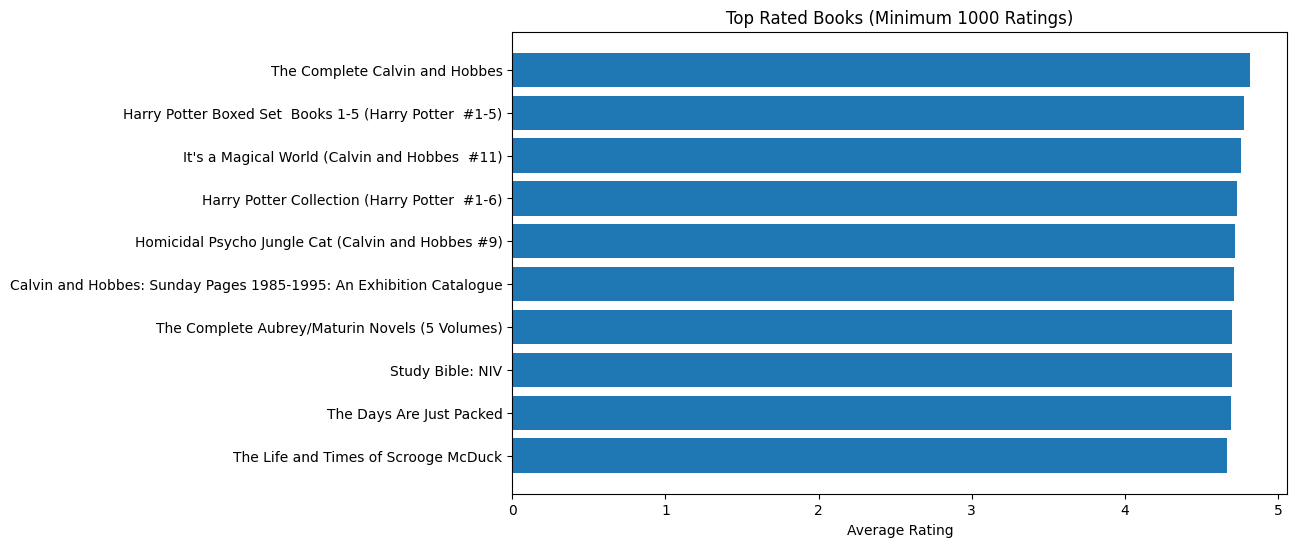

In [15]:
plt.figure(figsize=(10,6))

plt.barh(
    top_books["title"],
    top_books["average_rating"]
)

plt.title("Top Rated Books (Minimum 1000 Ratings)")
plt.xlabel("Average Rating")

plt.gca().invert_yaxis()

plt.show()

In [17]:
df.columns
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13', 'language_code', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date', 'publisher', 'year']


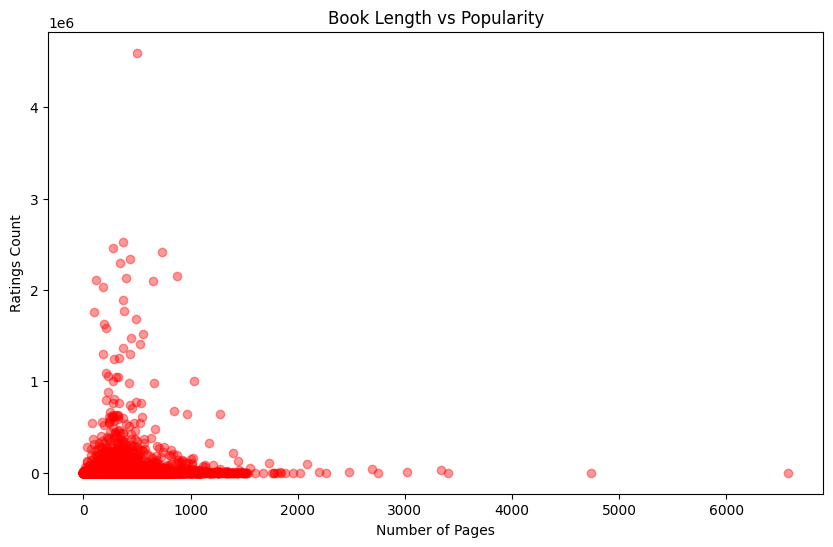

In [18]:
# does book length affect popularity
plt.figure(figsize=(10,6))

plt.scatter(
    df["num_pages"],
    df["ratings_count"],
    alpha=0.4,
    color="red"
)

plt.title("Book Length vs Popularity")
plt.xlabel("Number of Pages")
plt.ylabel("Ratings Count")

plt.show()

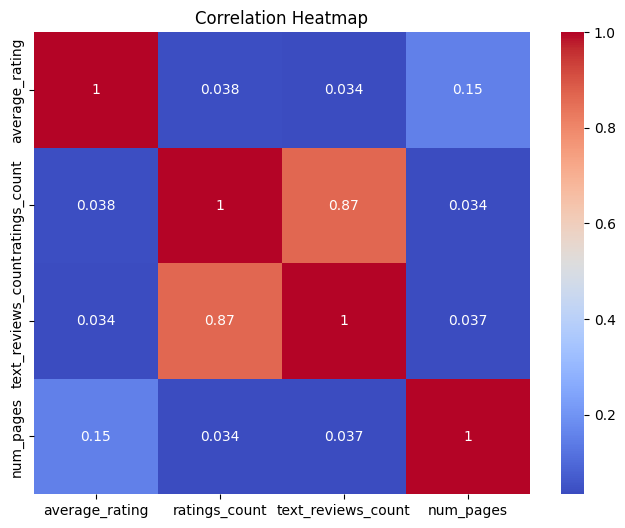

In [19]:
#relationships between numerical features
corr = df[
    ["average_rating",
     "ratings_count",
     "text_reviews_count",
     "num_pages"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()